In [33]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML

In [17]:
df = pd.read_csv("NYC.csv")
df.isna()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
1458639,False,False,False,False,False,False,False,False,False,False,False
1458640,False,False,False,False,False,False,False,False,False,False,False
1458641,False,False,False,False,False,False,False,False,False,False,False
1458642,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
df.fillna("unknown")

In [18]:
df[["pickup_datetime", "dropoff_datetime"]] = df[["pickup_datetime", "dropoff_datetime"]].apply(pd.to_datetime)

In [49]:
df["trip_duration_min"] = df["trip_duration"]/60
df_clean = df[(df["trip_duration_min"] >= 1) & (df["trip_duration_min"] <= 120)]

In [45]:
display(HTML("Results for original data"))
raw_mean = df["trip_duration_min"].mean()
raw_median = df["trip_duration_min"].median()
raw_max = df["trip_duration_min"].max()
raw_count = len(df)

print("Raw Row Count:", raw_count)
print("Raw Mean:", raw_mean, "mins")
print("Raw Median:", raw_median, "mins")
print("Raw Max:", raw_max, "mins")

print("\n")
display(HTML("results for cleaned data"))
clean_mean = df_clean["trip_duration_min"].mean()
clean_median = df_clean["trip_duration_min"].median()
clean_max = df_clean["trip_duration_min"].max()
clean_count = len(df_clean)

print("Clean Row Count:", clean_count)
print("Clean Mean:", clean_mean, "mins")
print("Clean Median:", clean_median, "mins")
print("Clean Max:", clean_max, "mins")

Raw Row Count: 1458644
Raw Mean: 15.991537882672764 mins
Raw Median: 11.033333333333333 mins
Raw Max: 58771.36666666667 mins




Clean Row Count: 1447796
Clean Mean: 14.014593630594366 mins
Clean Median: 11.083333333333334 mins
Clean Max: 119.85 mins


In [46]:
df["pickup_hour"] = df["pickup_datetime"].dt.hour
df["pickup_weekday"] = df["pickup_datetime"].dt.day_name()
df["weekday_num"] = df["pickup_datetime"].dt.dayofweek
df["pickup_month"] = df["pickup_datetime"].dt.month

In [47]:
hourly_counts = df_clean.groupby("pickup_hour").size()
print(hourly_counts)

# The top 3 pickup_hours
print("\nPeak hours")
top_3 = hourly_counts.sort_values(ascending = False).head(3)
print(top_3)
# The Bottom 3 pickup_hours
print("\nOff-Peak hours")
print(bottom_3)
bottom_3 = hourly_counts.sort_values(ascending = True).head(3)

pickup_hour
0     52775
1     38221
2     27661
3     20637
4     15524
5     14767
6     32933
7     55213
8     66662
9     67253
10    65032
11    68024
12    71370
13    70976
14    73697
15    71223
16    63758
17    75910
18    90022
19    89753
20    83536
21    83607
22    79936
23    69306
dtype: int64

Peak hours
pickup_hour
18    90022
19    89753
21    83607
dtype: int64

Off-Peak hours
pickup_hour
5    15002
4    15792
3    20895
dtype: int64


In [50]:
print("Peak hour:", hourly_counts.idxmax())
print("Off-peak hour:", hourly_counts.idxmin())

Peak hour: 18
Off-peak hour: 5


In [51]:
daily_counts = df_clean.groupby("weekday_num").size()
print(daily_counts)

weekday_num
0    186051
1    201318
2    208751
3    216947
4    221870
5    219190
6    193669
dtype: int64


In [52]:
# Aggregate trip count by weekday

weekday_counts = (
    df_clean.groupby(["weekday_num", "pickup_weekday"])
    .size()
    .sort_index()
)

print("Trips by weekday:")
print(weekday_counts)

Trips by weekday:
weekday_num  pickup_weekday
0            Monday            186051
1            Tuesday           201318
2            Wednesday         208751
3            Thursday          216947
4            Friday            221870
5            Saturday          219190
6            Sunday            193669
dtype: int64


In [53]:
# Monthly Trip Count
monthly_counts = (
    df_clean.groupby("pickup_month")
    .size()
)

print("Monthly trip counts:")
print(monthly_counts)

Monthly trip counts:
pickup_month
1    228064
2    236609
3    254306
4    249713
5    246579
6    232525
dtype: int64


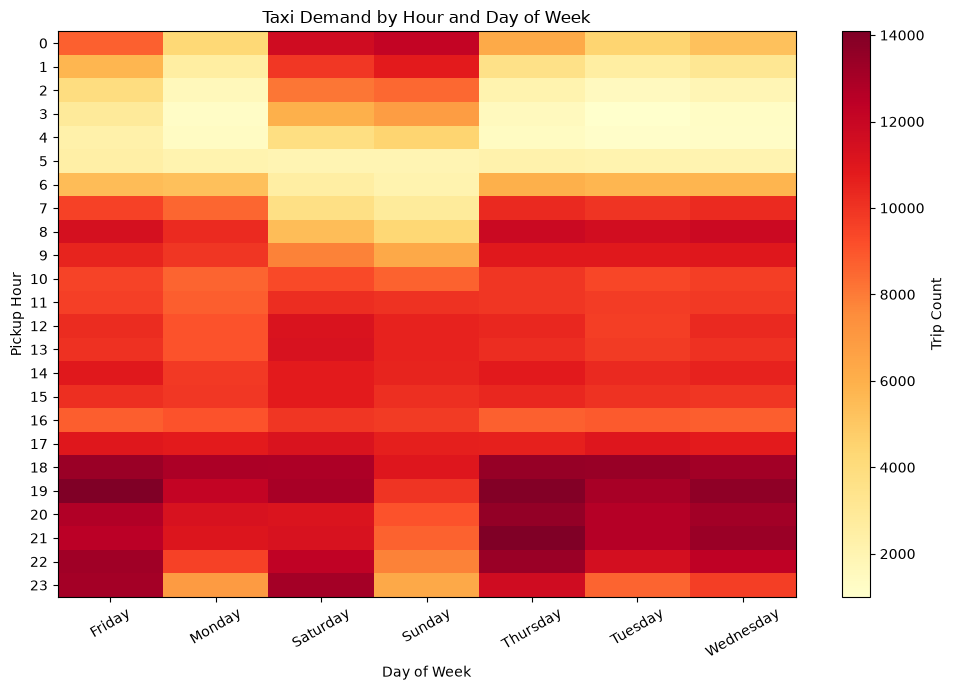

In [54]:
# Heatmap -Taxi Demand by Hour and Day of Week

heatmap_data = pd.pivot_table(
    df_clean,
    index="pickup_hour",
    columns="pickup_weekday",
    values="trip_duration_min",
    aggfunc="count",
    fill_value=0
)

plt.figure(figsize=(10, 7))

plt.imshow(heatmap_data, aspect="auto", cmap="YlOrRd")

plt.colorbar(label="Trip Count")

plt.xticks(range(len(heatmap_data.columns)), heatmap_data.columns, rotation=30)
plt.yticks(range(len(heatmap_data.index)), heatmap_data.index)

plt.xlabel("Day of Week")
plt.ylabel("Pickup Hour")
plt.title("Taxi Demand by Hour and Day of Week")

plt.tight_layout()
plt.show()

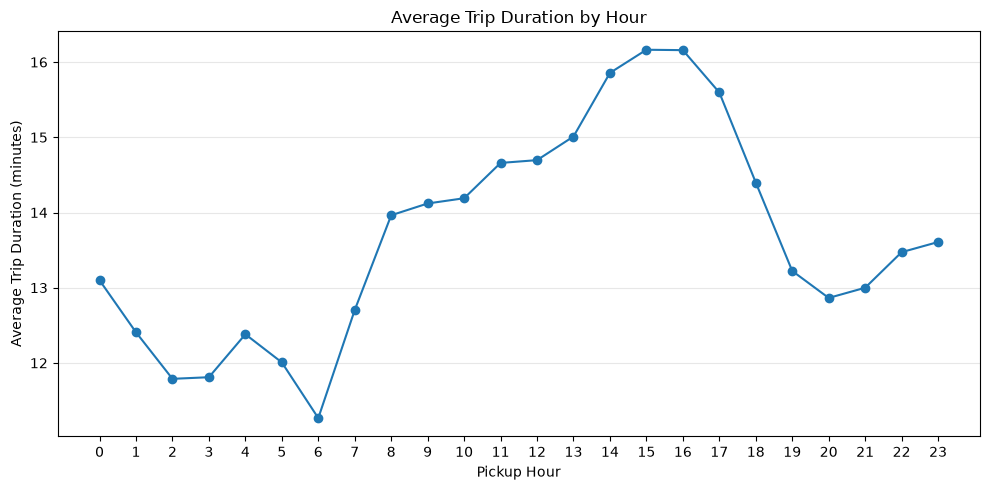

In [58]:
# Average Duration per Hour

avg_duration_by_hour = df_clean.groupby("pickup_hour")["trip_duration_min"].mean()

plt.figure(figsize=(10, 5))

plt.plot(
    avg_duration_by_hour.index,
    avg_duration_by_hour.values,
    marker="o"
)

plt.xlabel("Pickup Hour")
plt.ylabel("Average Trip Duration (minutes)")
plt.title("Average Trip Duration by Hour")
plt.xticks(range(24))
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()